In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Load Data:
import pandas as pd

df = pd.read_csv("Sample_Superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
#Check Shape:
df.shape

(10194, 21)

In [4]:
#Check missing values:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [5]:
#Remove duplicates:
df.drop_duplicates(inplace=True)

In [9]:
#Convert dates:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [11]:
#Create new columns:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

In [12]:
#Save cleaned data:
df.to_csv("cleaned_superstore.csv", index=False)

In [13]:
#Total Sales:
df['Sales'].sum()

np.float64(2326534.3543)

In [14]:
#Total Profit:
df['Profit'].sum()

np.float64(292296.8146)

In [17]:
#Top Product:
df.groupby('Sub-Category')['Sales'] \
.sum() \
.sort_values(ascending=False)

Sub-Category
Chairs         335768.2490
Phones         331842.6400
Storage        224644.5540
Tables         208020.1820
Binders        207354.8810
Machines       189925.0310
Accessories    167380.3180
Copiers        150745.2900
Bookcases      115361.2043
Appliances     108213.1850
Furnishings     95598.1260
Paper           79540.5380
Supplies        46725.4980
Art             27659.0140
Envelopes       16528.3620
Labels          12695.0420
Fasteners        8532.2400
Name: Sales, dtype: float64

In [19]:
#Sales by Region:
df.groupby('Region')['Sales'] \
.sum() \
.sort_values(ascending=False)

Region
West       739813.6085
East       691828.1680
Central    503170.6728
South      391721.9050
Name: Sales, dtype: float64

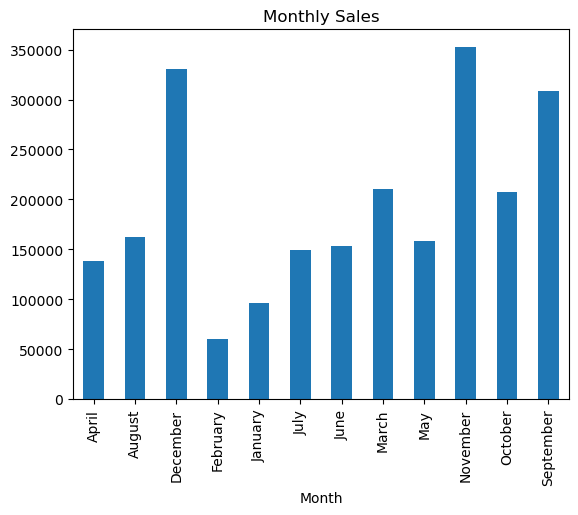

In [20]:
#Monthly Sales Trend:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='bar')

plt.title("Monthly Sales")
plt.show()

<Axes: xlabel='Region'>

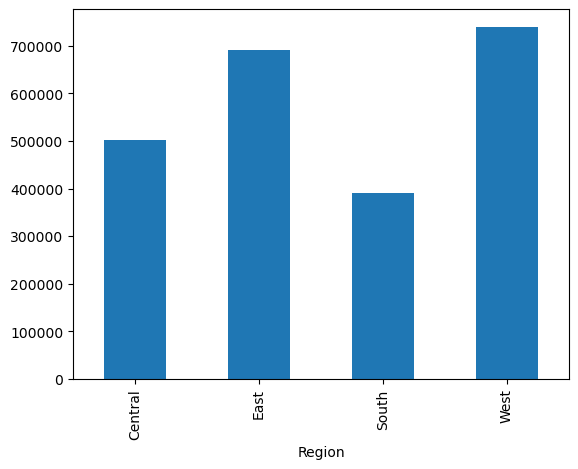

In [21]:
#Region Sales:
df.groupby('Region')['Sales'] \
.sum() \
.plot(kind='bar')